libaraies

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [2]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"


# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")
RI1_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv")
RI2_1_1_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv")
RI1_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv")
RI2_1_2_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv")
RI1_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv")
RI2_2_4_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv")
RI2_3_5_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv")


In [3]:
ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

In [4]:
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [5]:
ri1_boris_data = {
    "RI1_3_6": RI1_3_6_boris.copy(),
    "RI1_4_7": RI1_4_7_boris.copy(),
    "RI1_2_3": RI1_2_3_boris.copy(),
    "RI1_4_8": RI1_4_8_boris.copy(),
    "RI1_1_1": RI1_1_1_boris.copy(),
    "RI1_1_2": RI1_1_2_boris.copy(),
    "RI1_2_4": RI1_2_4_boris.copy(),
}


In [6]:
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
    "RI2_1_1": RI2_1_1_boris.copy(),
    "RI2_1_2": RI2_1_2_boris.copy(),
    "RI2_2_4": RI2_2_4_boris.copy(),
    "RI2_3_5": RI2_3_5_boris.copy(),
}


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [35]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [36]:
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [37]:
resp_data = {}

for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("✅ All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
Processing RI1_1_1...
Processing RI2_1_1...
Processing RI1_1_2...
Processing RI2_1_2...
Processing RI1_2_4...
Processing RI2_2_4...
Processing RI1_3_5...
Processing RI2_3_5...
✅ All available signals loaded.


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [10]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

In [11]:
def extract_agent_face_sniffs(df):
    """
    Filters BORIS dataframe for facial sniffing initiated by the social agent.
    """
    df = df.copy()
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Updated filters
    agent_mask = df['Subject'].str.lower() == 'social_agent'
    sniff_mask = df['Behavior'].str.lower() == 'facial sniffing'

    return df[agent_mask & sniff_mask]


RUN LOOP ON ALL SUBJECTS WORKS

In [34]:
all_agent_sniffs = []

# Process RI1
for label, boris_df in ri1_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs(boris_df)
    agent_sniffs["Trial"] = label
    all_agent_sniffs.append(agent_sniffs)

# Process RI2
for label, boris_df in ri2_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs(boris_df)
    agent_sniffs["Trial"] = label
    all_agent_sniffs.append(agent_sniffs)

combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)
print(combined_sniffs_df[['Trial', 'Subject', 'Behavior', 'Start (s)', 'Stop (s)']].head())


     Trial       Subject         Behavior  Start (s)  Stop (s)
0  RI1_3_6  social_agent  facial sniffing     12.069    12.862
1  RI1_3_6  social_agent  facial sniffing     86.207    87.414
2  RI1_3_6  social_agent  facial sniffing     88.034    88.828
3  RI1_3_6  social_agent  facial sniffing    107.724   108.483
4  RI1_3_6  social_agent  facial sniffing    183.724   184.621


In [39]:
combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)
print("Trials in combined_sniffs_df:")
print(combined_sniffs_df['Trial'].unique())
print(f"DataFrame shape: {combined_sniffs_df.shape}")
print(combined_sniffs_df['Trial'].value_counts())


Trials in combined_sniffs_df:
['RI1_3_6' 'RI1_4_7' 'RI1_2_3' 'RI1_4_8' 'RI1_1_1' 'RI1_1_2' 'RI1_2_4'
 'RI2_3_6' 'RI2_4_7' 'RI2_2_3' 'RI2_4_8' 'RI2_1_1' 'RI2_1_2' 'RI2_2_4'
 'RI2_3_5']
DataFrame shape: (181, 29)
Trial
RI2_4_8    38
RI2_3_6    26
RI2_4_7    21
RI2_1_2    17
RI1_3_6    14
RI1_4_8    14
RI2_2_4    13
RI2_2_3    12
RI1_2_4     7
RI1_4_7     6
RI2_3_5     6
RI2_1_1     4
RI1_2_3     1
RI1_1_1     1
RI1_1_2     1
Name: count, dtype: int64


In [32]:
print(combined_sniffs_df['Trial'].unique())


['RI2_3_6' 'RI2_4_7' 'RI2_2_3' 'RI2_4_8' 'RI2_1_1' 'RI2_1_2' 'RI2_2_4'
 'RI2_3_5']


In [26]:
def calculate_percent_change_resp_rate_with_post(signal, time, sniff_start, sampling_rate=100, plot=False,
                                                baseline_color='gray', sniff_color='orange', post_color='green', title=None):
    """
    Calculates % change in respiration rate (Hz) around a sniff event including a post-sniff window.

    Windows:
    - Baseline: -5s to -1s before sniff_start
    - During sniff: 0s to +0.5s after sniff_start
    - Post-sniff: +0.5s to +1.5s after sniff_start

    Returns:
        percent_change_sniff, percent_change_post,
        baseline_mean_rate, sniff_mean_rate, post_mean_rate
    """
    import numpy as np
    from scipy.signal import find_peaks
    import matplotlib.pyplot as plt

    baseline_mask = (time >= sniff_start - 5) & (time < sniff_start - 1)
    sniff_mask = (time >= sniff_start) & (time < sniff_start + 0.5)
    post_mask = (time >= sniff_start + 0.5) & (time < sniff_start + 1.5)

    baseline_segment = signal[baseline_mask]
    sniff_segment = signal[sniff_mask]
    post_segment = signal[post_mask]

    min_distance_samples = int(0.0833 * sampling_rate)  # 75ms min between breaths

    baseline_peaks, _ = find_peaks(baseline_segment, distance=min_distance_samples)
    sniff_peaks, _ = find_peaks(sniff_segment, distance=min_distance_samples)
    post_peaks, _ = find_peaks(post_segment, distance=min_distance_samples)

    baseline_peak_times = time[baseline_mask][baseline_peaks]
    sniff_peak_times = time[sniff_mask][sniff_peaks]
    post_peak_times = time[post_mask][post_peaks]

    baseline_ibis = np.diff(baseline_peak_times)
    sniff_ibis = np.diff(sniff_peak_times)
    post_ibis = np.diff(post_peak_times)

    if len(baseline_ibis) == 0 or len(sniff_ibis) == 0 or len(post_ibis) == 0:
        if plot:
            print("Not enough peaks detected to calculate respiration rate change.")
        return None, None, None, None, None

    baseline_rates = 1 / baseline_ibis
    sniff_rates = 1 / sniff_ibis
    post_rates = 1 / post_ibis

    baseline_mean_rate = np.mean(baseline_rates)
    sniff_mean_rate = np.mean(sniff_rates)
    post_mean_rate = np.mean(post_rates)

    percent_change_sniff = ((sniff_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100
    percent_change_post = ((post_mean_rate - baseline_mean_rate) / baseline_mean_rate) * 100

    if plot:
        plt.figure(figsize=(6, 4))
        plt.bar(['Baseline', 'During Sniff', 'Post Sniff'], 
                [baseline_mean_rate, sniff_mean_rate, post_mean_rate],
                color=[baseline_color, sniff_color, post_color])
        plt.ylabel('Respiration Rate (Hz)')
        plt.title(title or f'Respiration Rate Change\nDuring Sniff: {percent_change_sniff:.2f}%, Post Sniff: {percent_change_post:.2f}%')
        plt.show()

    return percent_change_sniff, percent_change_post, baseline_mean_rate, sniff_mean_rate, post_mean_rate


In [27]:
import pandas as pd

all_agent_sniffs = []

# Collect all agent face sniffs from each trial
for label, boris_df in ri2_boris_data.items():
    agent_sniffs = extract_agent_face_sniffs(boris_df)
    agent_sniffs["Trial"] = label
    all_agent_sniffs.append(agent_sniffs)

combined_sniffs_df = pd.concat(all_agent_sniffs, ignore_index=True)

agent_sniff_results = []

for i, sniff_row in combined_sniffs_df.iterrows():
    trial = sniff_row["Trial"]
    sniff_start = sniff_row["Start (s)"]

    resp_entry = resp_data.get(trial)
    if resp_entry is None:
        print(f"Missing respiration data for {trial}, skipping...")
        continue

    signal = resp_entry["signal"]
    time = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    pct_change_sniff, pct_change_post, baseline_rate, sniff_rate, post_rate = calculate_percent_change_resp_rate_with_post(
        signal, time, sniff_start, sampling_rate=sampling_rate, plot=False
    )

    if pct_change_sniff is None:
        print(f"Not enough peaks for sniff at {sniff_start}s in {trial}, skipping...")
        continue

    agent_sniff_results.append({
        "Trial": trial,
        "Sniff Start": sniff_start,
        "Percent Change Sniff": pct_change_sniff,
        "Percent Change Post": pct_change_post,
        "Baseline Rate": baseline_rate,
        "Sniff Rate": sniff_rate,
        "Post Rate": post_rate
    })

agent_sniff_df = pd.DataFrame(agent_sniff_results)
print(agent_sniff_df.head())


Not enough peaks for sniff at 153.9s in RI2_3_6, skipping...
Not enough peaks for sniff at 224.267s in RI2_4_8, skipping...
Not enough peaks for sniff at 488.333s in RI2_4_8, skipping...
Not enough peaks for sniff at 496.633s in RI2_4_8, skipping...
     Trial  Sniff Start  Percent Change Sniff  Percent Change Post  \
0  RI2_3_6       25.600              2.198297            -2.789403   
1  RI2_3_6       68.767             26.203801             3.768623   
2  RI2_3_6       91.900             18.355420            -0.964383   
3  RI2_3_6      156.233             44.675293            20.046722   
4  RI2_3_6      195.433            126.066619            52.468082   

   Baseline Rate  Sniff Rate  Post Rate  
0       8.401176    8.585859   8.166833  
1       7.977050   10.067340   8.277675  
2       9.074989   10.740741   8.987471  
3       5.316946    7.692308   6.382820  
4       4.638505   10.486111   7.072239  


In [43]:
print(agent_sniff_df['Trial'].unique())
print(agent_sniff_df['Valence'].value_counts())


['RI2_3_6' 'RI2_4_7' 'RI2_2_3' 'RI2_4_8' 'RI2_1_1' 'RI2_1_2' 'RI2_2_4'
 'RI2_3_5']
Valence
Negative    133
Name: count, dtype: int64


C:\Users\sjs93\AppData\Local\Temp\ipykernel_38780\4180150131.py:49: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(


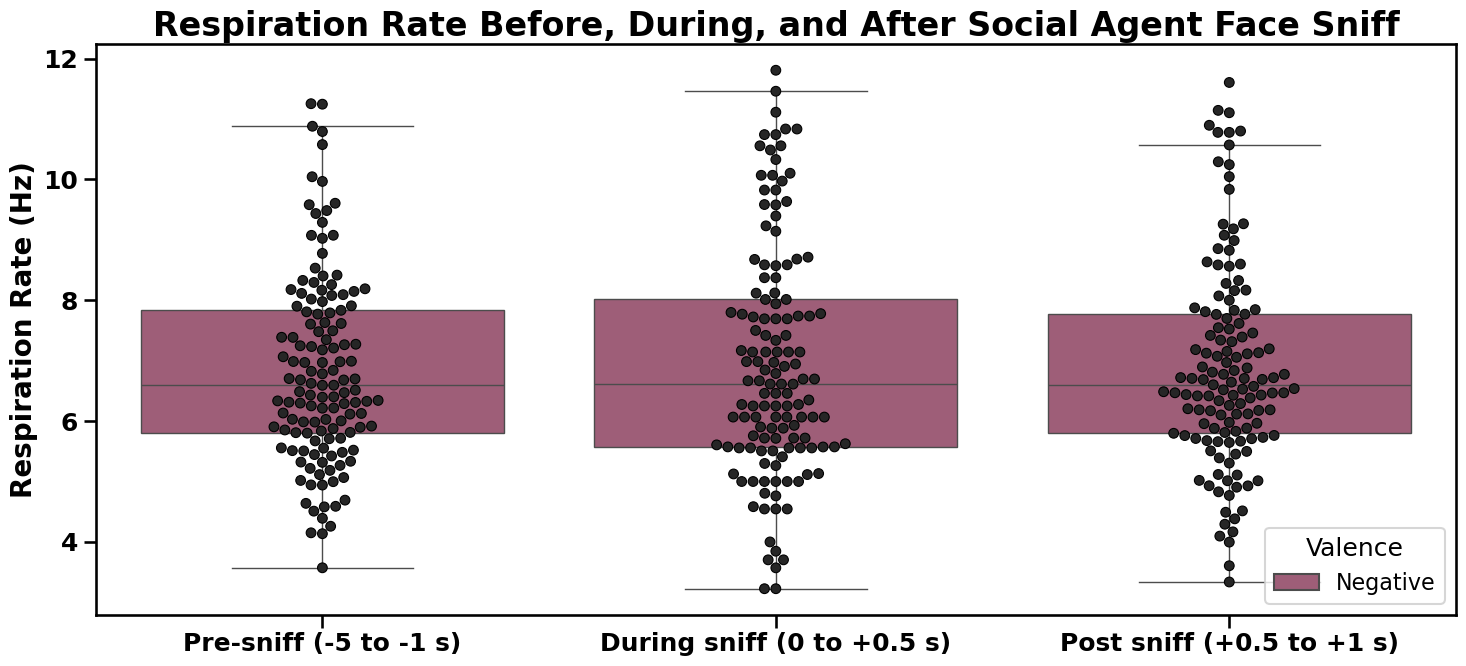

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add 'Valence' and 'ConditionGroup' columns based on Trial string
agent_sniff_df['Valence'] = agent_sniff_df['Trial'].apply(
    lambda x: 'Positive' if 'RI1' in x else ('Negative' if 'RI2' in x else 'Unknown')
)
agent_sniff_df['ConditionGroup'] = agent_sniff_df['Trial'].apply(
    lambda x: 'RI1' if 'RI1' in x else ('RI2' if 'RI2' in x else 'Unknown')
)

# Remove unknowns just in case
agent_sniff_df = agent_sniff_df[agent_sniff_df['Valence'] != 'Unknown']

# Melt the DataFrame for easier plotting with seaborn
plot_df = agent_sniff_df.melt(
    id_vars=["Trial", "Valence", "ConditionGroup"],
    value_vars=["Baseline Rate", "Sniff Rate", "Post Rate"],
    var_name="Respiration Condition",
    value_name="Respiration Rate (Hz)"
)

# Rename conditions for readability on plot
plot_df["Respiration Condition"] = plot_df["Respiration Condition"].replace({
    "Baseline Rate": "Pre-sniff (-5 to -1 s)",
    "Sniff Rate": "During sniff (0 to +0.5 s)",
    "Post Rate": "Post sniff (+0.5 to +1 s)"
})

# Plot setup
plt.figure(figsize=(15, 7))
sns.set_context("talk")
custom_palette = {
    'Positive': (83/255, 161/255, 169/255),
    'Negative': (169/255, 83/255, 118/255)
}

# Boxplot
sns.boxplot(
    x="Respiration Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    palette=custom_palette,
    fliersize=0
)

# Swarmplot overlay for individual points
sns.swarmplot(
    x="Respiration Condition",
    y="Respiration Rate (Hz)",
    hue="Valence",
    data=plot_df,
    dodge=True,
    color='black',
    edgecolor='black',
    alpha=1,
    size=7,
    marker='o',
    linewidth=0.8,
    legend=False
)

# Labels and legend
plt.title("Respiration Rate Before, During, and After Social Agent Face Sniff", fontsize=24, weight='bold')
plt.ylabel("Respiration Rate (Hz)", fontsize=20, weight='bold')
plt.xlabel("")
plt.xticks(fontsize=18, weight='bold')
plt.yticks(fontsize=18, weight='bold')
plt.legend(title='Valence', fontsize=16, title_fontsize=18, loc='lower right', bbox_to_anchor=(1, 0))
plt.tight_layout()
plt.show()
